In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


from sklearn.decomposition import PCA

import seaborn as sns
from sklearn.manifold import TSNE

import lissa as li

In [2]:
entireData = pd.read_csv("../data/totalProcessedData.csv")
entireData.drop(columns="Unnamed: 0",inplace=True)

/tmp/ipykernel_81108/1122376188.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  entireData = pd.read_csv("../data/totalProcessedData.csv")


In [3]:
entireData["Failure"]=entireData["Failure"].astype(bool)

entireData["time"] = pd.to_datetime(entireData["index"])
entireData.set_index("time",inplace=True)
entireData.drop(columns="index",inplace=True)

pumpList = entireData["Well Run"].unique()

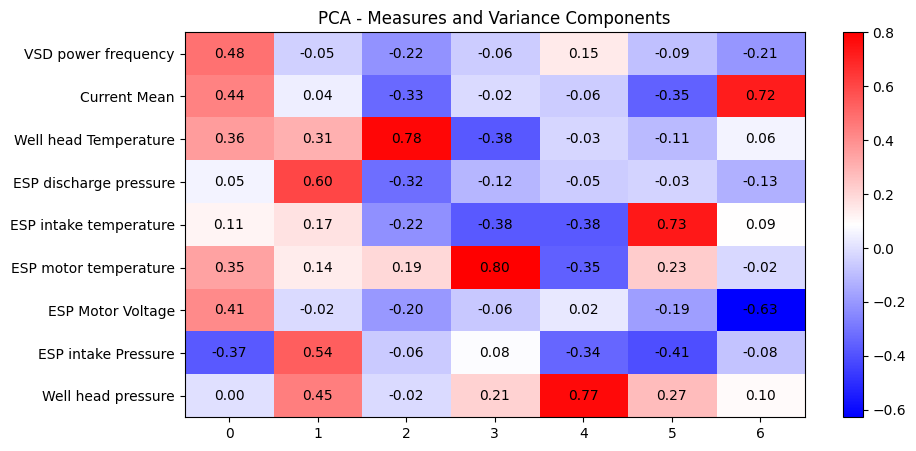

[0.33049308 0.51562954 0.64629379 0.74709831 0.8346246  0.90668578
 0.95123479]


In [9]:
n = 7

operationalHeaders = li.operationalHeader(entireData)

pca = li.ApplyPCA(entireData, n)
li.FigureComponents(pca,"PCA - Measures and Variance Components",operationalHeaders)
PCAdata = li.ReducePCA(pca, n, operationalHeaders,entireData)


PCAdata = li.ExportPCAData(PCAdata,entireData)
# PCAdata.to_csv("../data/PCA/PCAtotal.csv")

(<Figure size 4000x1700 with 4 Axes>,
 array([<Axes: xlabel='time'>, <Axes: >, <Axes: xlabel='time'>],
       dtype=object))

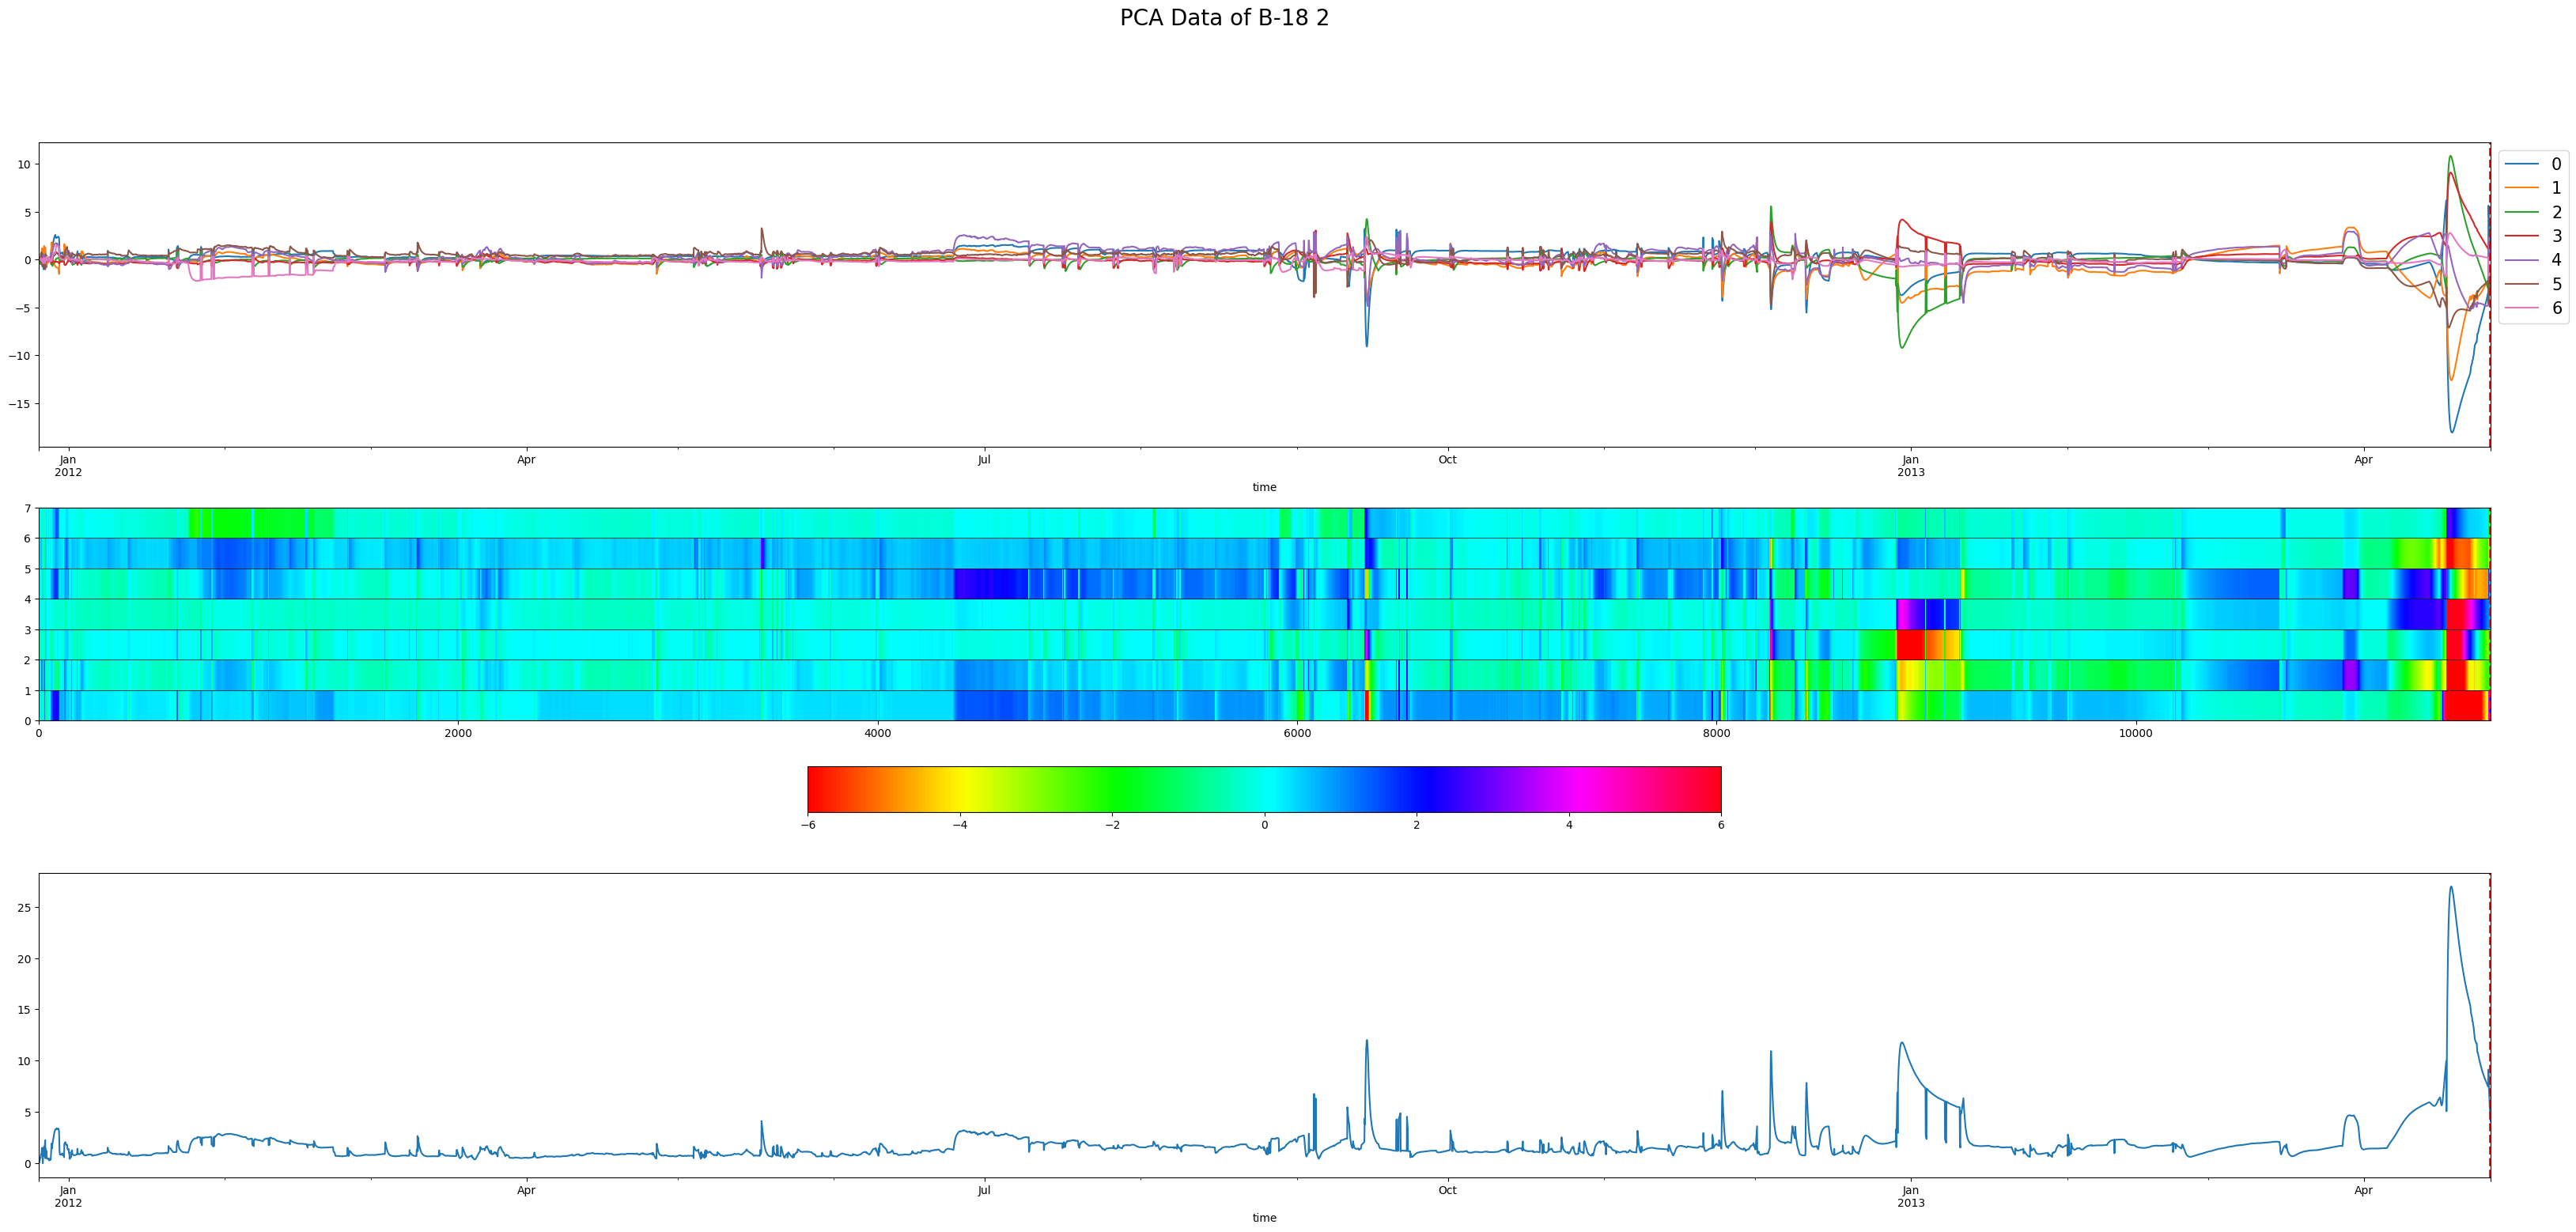

In [10]:
pump = pumpList[0]

# pumpData = PCALF.loc[PCALF["Well Run"]==pump].copy()

# PCAHeaders = [i for i in range(0,componentsLF)]

pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()

PCAHeaders = [str(i) for i in range(0,n)]


li.PCAComponentsPlot(pumpData,pump,PCAHeaders)


7.5

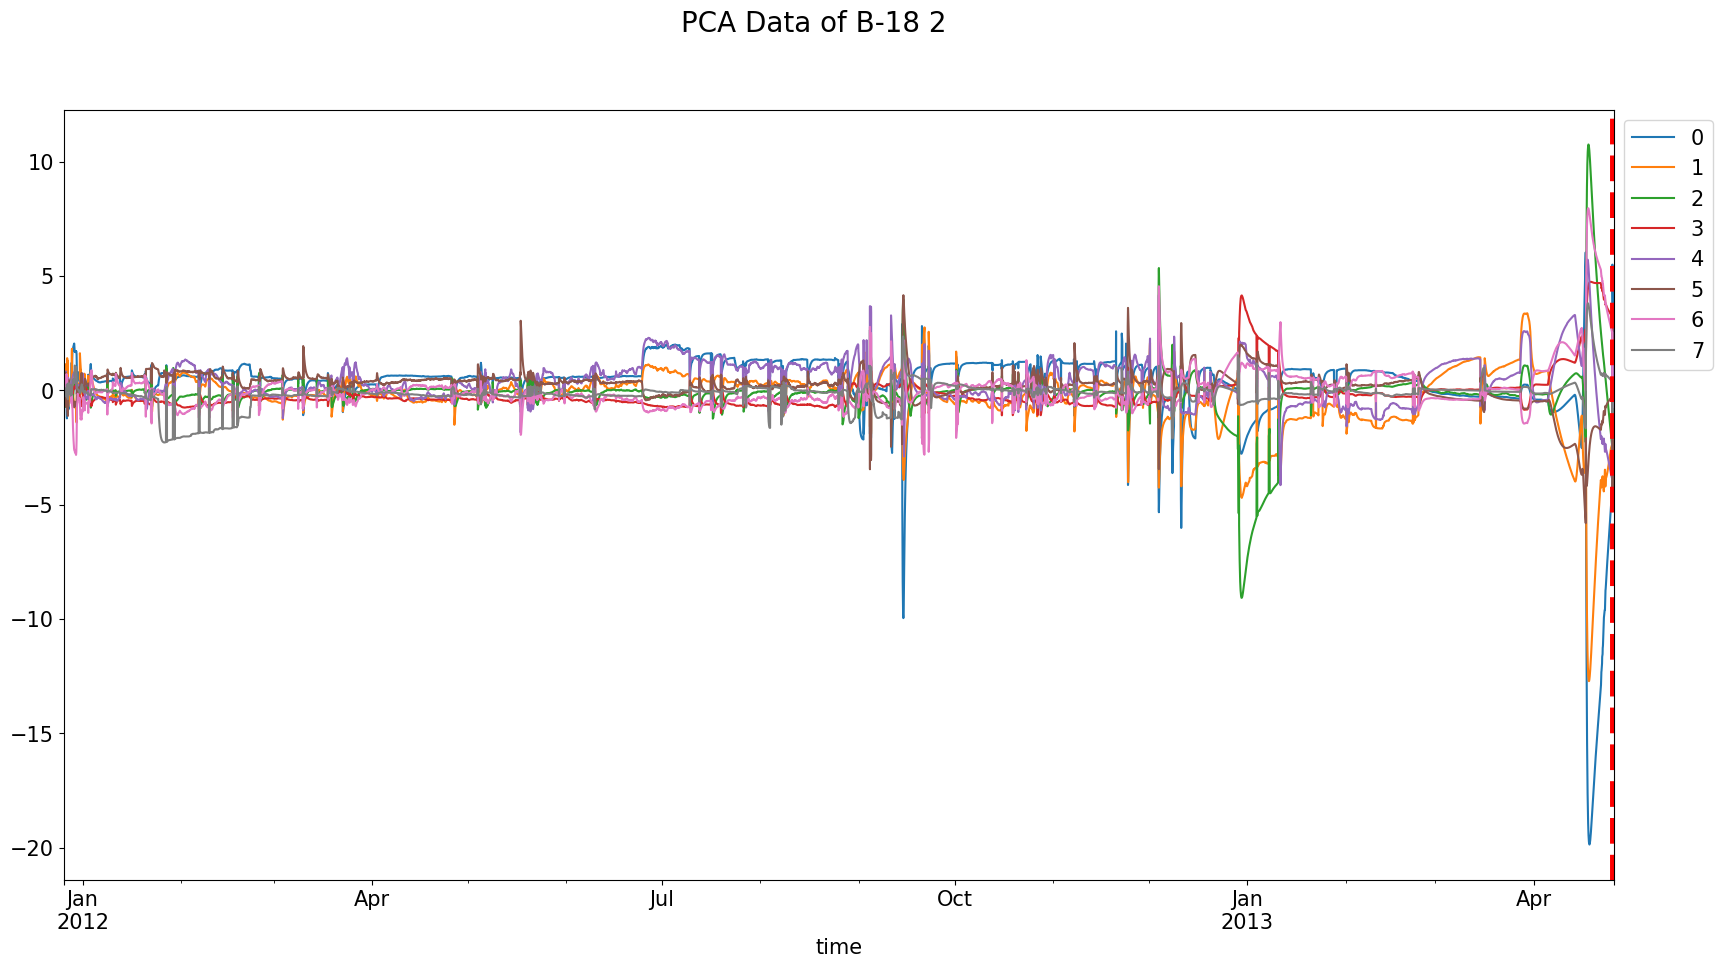

In [8]:
pump = pumpList[0]
plt.rcParams['font.size'] = 15.0

pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()

fig, ax = plt.subplots(1,1, figsize=(20,10))

pumpData[PCAHeaders].plot(ax=ax)

ax.axvline(pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)
ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)

fig.suptitle("PCA Data of " + pump,fontsize=20);


factor = 0.5


plt.rcParams.update({
    'font.size': plt.rcParams['font.size'] * factor,
})

#fig.savefig("imagens/relatorio/PCAapplied")

plt.rcParams['font.size']

In [10]:
for pump in pumpList:
    pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()

    fig, axs = li.PCAComponentsPlot(pumpData,pump,PCAHeaders)

    fig.savefig("imagens/PCAapplied/pump"+pump)
    plt.close()
    